In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_data.csv')

In [49]:
# show the first 5 rows
df.head()


,Starting (USD),Ending (USD)
0,15800,15300
1,15800,15500
2,15900,16100
3,15900,16200
4,16100,16200


In [50]:
# show the last 5 rows
df.tail()

,Starting (USD),Ending (USD)
6,16200,16200
7,16300,15700
8,16300,15800
9,16800,16400
10,16800,16500


In [13]:
# Random Rows
df.sample(5)

,Date,Starting (USD),Ending (USD)
5,01.08.23,16800,16400
3,01.10.23,16100,16200
9,01.04.23,16300,15800
4,01.09.23,16300,15700
2,01.11.23,15800,15300


In [51]:
# Shape
df.shape

(11, 2)

In [52]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Starting (USD)  11 non-null     int64
 1   Ending (USD)    11 non-null     int64
dtypes: int64(2)
memory usage: 308.0 bytes


In [16]:
# Summary Statistics
df.describe()

,Starting (USD),Ending (USD)
count,12.000000,12.000000
mean,16195.833333,15975.000000
std,338.753285,369.582074
min,15800.000000,15300.000000
25%,15900.000000,15700.000000
50%,16175.000000,16100.000000
75%,16300.000000,16200.000000
max,16800.000000,16500.000000


In [53]:
# Summary Statistics for all columns
df.describe(include="all")

,Starting (USD),Ending (USD)
count,11.000000,11.000000
mean,16186.363636,16000.000000
std,353.617667,376.828874
min,15800.000000,15300.000000
25%,15900.000000,15750.000000
50%,16150.000000,16100.000000
75%,16300.000000,16200.000000
max,16800.000000,16500.000000


In [36]:
# Drop Unnecessary Columns
df.drop("Date", axis=1, inplace=True, errors="ignore")
df

,Starting (USD),Ending (USD)
0,15800,15300
1,15800,15500
2,15900,16100
3,15900,16200
4,16100,16200
5,16150,16100
6,16200,16200
7,16300,15700
8,16300,15800
9,16800,16400


In [54]:
# Count Missing Values
df.isnull().sum()

Starting (USD)    0
Ending (USD)      0
dtype: int64

In [55]:
df.duplicated()
df.drop_duplicates(inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300
1,15800,15500
2,15900,16100
3,15900,16200
4,16100,16200
5,16150,16100
6,16200,16200
7,16300,15700
8,16300,15800
9,16800,16400


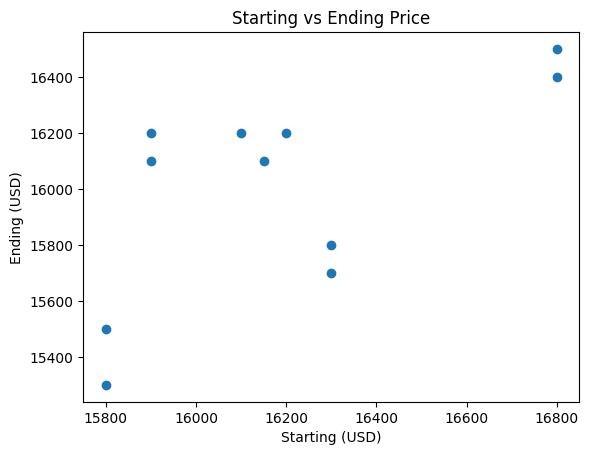

In [56]:
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.title('Starting vs Ending Price')
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.show()

In [57]:
# Outliers Detection
Q1 = df["Starting (USD)"].quantile(0.25)
Q3 = df["Starting (USD)"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Starting (USD)"] < lower) |
    (df["Starting (USD)"] > upper)
]
print(outliers)

Empty DataFrame
Columns: [Starting (USD), Ending (USD)]
Index: []


In [58]:
# Multiple Numeric Columns Outliers
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[
    (df[col] >= lower) &
    (df[col] <= upper)
    ]
df

,Starting (USD),Ending (USD)
0,15800,15300
1,15800,15500
2,15900,16100
3,15900,16200
4,16100,16200
5,16150,16100
6,16200,16200
7,16300,15700
8,16300,15800
9,16800,16400


In [59]:
df.sort_values(["Starting (USD)", "Ending (USD)"], inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300
1,15800,15500
2,15900,16100
3,15900,16200
4,16100,16200
5,16150,16100
6,16200,16200
7,16300,15700
8,16300,15800
9,16800,16400


In [60]:
# Split the data into training and testing sets
features = df.drop("Ending (USD)", axis=1)
target = df["Ending (USD)"]

In [61]:
features

,Starting (USD)
0,15800
1,15800
2,15900
3,15900
4,16100
5,16150
6,16200
7,16300
8,16300
9,16800


In [62]:
target

0     15300
1     15500
2     16100
3     16200
4     16200
5     16100
6     16200
7     15700
8     15800
9     16400
10    16500
Name: Ending (USD), dtype: int64

In [63]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 232.52173913043467
Mean Squared Error: 104413.69124133566
R2 Score: 0.5156065870247314


In [ ]:

# y = mx + c
m = model.coef_
c = model.intercept_


[0.48347826]
8210.782608695652


In [64]:
features.mean()

Starting (USD)    16186.363636
dtype: float64